### POC ML for Futures Trading


In [34]:
# Load API key from .env file
from dotenv import load_dotenv
import os

load_dotenv()  # Load environment variables from .env file
api_key = os.environ.get('POLYGON_API_KEY')

if api_key:
    print(f"✅ API key loaded successfully (length: {len(api_key)} chars)")
else:
    print("⚠️ POLYGON_API_KEY not found in .env file!")
    print("   Create a .env file in the trading_brains folder with:")
    print("   POLYGON_API_KEY=your-api-key-here")

✅ API key loaded successfully (length: 32 chars)


In [19]:
# =============================================================================
# Data Import from Polygon.io (Massive) - 1-Minute Stock Data
# =============================================================================
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

# Load API key from environment

def fetch_polygon_1min_data(symbol: str, start_date: str, end_date: str, api_key: str) -> pd.DataFrame:
    """
    Fetch 1-minute OHLCV data from Polygon.io
    
    Args:
        symbol: Stock ticker symbol (e.g., 'SPY', 'QQQ', 'IWM')
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format
        api_key: Polygon.io API key
    
    Returns:
        DataFrame with columns: timestamp, open, high, low, close, volume, vwap
    """
    all_data = []
    multiplier = 1
    timespan = "minute"
    
    url = f"https://api.polygon.io/v2/aggs/ticker/{symbol}/range/{multiplier}/{timespan}/{start_date}/{end_date}"
    
    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 50000,
        "apiKey": api_key
    }
    
    print(f"Fetching {symbol} data from {start_date} to {end_date}...")
    
    while url:
        response = requests.get(url, params=params)
        
        if response.status_code != 200:
            print(f"❌ Error: {response.status_code} - {response.text}")
            break
            
        data = response.json()
        
        if data.get("results"):
            all_data.extend(data["results"])
            print(f"  Fetched {len(data['results'])} bars (total: {len(all_data)})")
        
        # Handle pagination
        url = data.get("next_url")
        if url:
            params = {"apiKey": api_key}
            time.sleep(0.15)  # Rate limiting
    
    if not all_data:
        print("❌ No data received")
        return pd.DataFrame()
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Rename columns to standard format
    df = df.rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "num_trades"
    })
    
    # Convert timestamp from milliseconds to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("timestamp")
    
    # Select relevant columns
    cols = ["open", "high", "low", "close", "volume"]
    if "vwap" in df.columns:
        cols.append("vwap")
    
    df = df[cols]
    
    print(f"✅ Loaded {len(df)} 1-minute bars for {symbol}")
    print(f"   Date range: {df.index.min()} to {df.index.max()}")
    
    return df

# Example: Fetch SPY (S&P 500 ETF) as a proxy for index
# Polygon free tier: 2 years of historical data
# Adjust dates as needed
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%d")  # Last 30 days

# Uncomment to fetch data:
df = fetch_polygon_1min_data("SPY", start_date, end_date, api_key)

Fetching SPY data from 2025-12-31 to 2026-01-30...
  Fetched 18326 bars (total: 18326)
✅ Loaded 18326 1-minute bars for SPY
   Date range: 2025-12-31 09:00:00 to 2026-01-30 00:59:00


In [20]:
df.head()

,open,high,low,close,volume,vwap
timestamp,,,,,,
2025-12-31 09:00:00,685.14,685.30,685.00,685.30,6267.0,685.0831
2025-12-31 09:01:00,685.38,685.38,685.34,685.38,586.0,685.3682
2025-12-31 09:02:00,685.42,685.46,685.42,685.46,220.0,685.4509
2025-12-31 09:03:00,685.46,685.47,685.45,685.45,342.0,685.4574
2025-12-31 09:04:00,685.51,685.52,685.50,685.50,364.0,685.5063


# Feature Engineering

- Creation of common metrics for time-series
- RSI, MACD, Bollinger Mavg, ATR, Stochastic-K, Return 1, Return 5, Rolling Average 30, 60, 90, 120, Volatility

In [21]:
# =============================================================================
# Data Preparation - Standardize column names and validate data
# =============================================================================

# Standardize column names to capitalized format (Open, High, Low, Close, Volume)
df.columns = df.columns.str.capitalize()

# Display data info
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"\n📊 DataFrame shape: {df.shape}")
print(f"📅 Date range: {df.index.min()} to {df.index.max()}")
print(f"🕐 Frequency: 1-minute bars")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 Missing values per column:")
print(df.isnull().sum())

print(f"\n📈 First few rows:")
print(df.head())

print(f"\n📉 Last few rows:")
print(df.tail())

DATA SUMMARY

📊 DataFrame shape: (18326, 6)
📅 Date range: 2025-12-31 09:00:00 to 2026-01-30 00:59:00
🕐 Frequency: 1-minute bars

📋 Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap']

🔍 Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
Vwap      0
dtype: int64

📈 First few rows:
                       Open    High     Low   Close  Volume      Vwap
timestamp                                                            
2025-12-31 09:00:00  685.14  685.30  685.00  685.30  6267.0  685.0831
2025-12-31 09:01:00  685.38  685.38  685.34  685.38   586.0  685.3682
2025-12-31 09:02:00  685.42  685.46  685.42  685.46   220.0  685.4509
2025-12-31 09:03:00  685.46  685.47  685.45  685.45   342.0  685.4574
2025-12-31 09:04:00  685.51  685.52  685.50  685.50   364.0  685.5063

📉 Last few rows:
                         Open      High       Low     Close  Volume      Vwap
timestamp                                                                    
2026-01-30 

In [22]:
# =============================================================================
# FEATURE ENGINEERING - Technical Indicators for 1-Minute Data
# =============================================================================
import numpy as np

def calculate_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Relative Strength Index"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    """Calculate MACD, Signal line, and Histogram"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def calculate_bollinger_bands(prices: pd.Series, period: int = 20, std_dev: float = 2.0):
    """Calculate Bollinger Bands"""
    middle = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper = middle + (std * std_dev)
    lower = middle - (std * std_dev)
    return middle, upper, lower

def calculate_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Average True Range"""
    tr1 = high - low
    tr2 = abs(high - close.shift())
    tr3 = abs(low - close.shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def calculate_stochastic(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Stochastic Oscillator %K"""
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    return 100 * (close - lowest_low) / (highest_high - lowest_low)

# Apply feature engineering to df
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# OHLC Standard Deviation (intraday volatility measure)
df['OHLC_Std'] = df[['Open', 'High', 'Low', 'Close']].std(axis=1)

# RSI
df['RSI'] = calculate_rsi(df['Close'], period=14)

# MACD
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = calculate_macd(df['Close'])

# Bollinger Bands
df['BB_Middle'], df['BB_Upper'], df['BB_Lower'] = calculate_bollinger_bands(df['Close'], period=20)

# ATR (Average True Range)
df['ATR'] = calculate_atr(df['High'], df['Low'], df['Close'], period=14)

# Stochastic Oscillator
df['Stochastic_K'] = calculate_stochastic(df['High'], df['Low'], df['Close'], period=14)

# Returns (1-bar and 5-bar)
df['Return_1'] = df['Close'].pct_change(1)
df['Return_5'] = df['Close'].pct_change(5)

# Simple Moving Averages (adjusted for 1-minute data)
df['SMA_30'] = df['Close'].rolling(window=30).mean()    # 30-minute SMA
df['SMA_60'] = df['Close'].rolling(window=60).mean()    # 1-hour SMA
df['SMA_120'] = df['Close'].rolling(window=120).mean()  # 2-hour SMA
df['SMA_390'] = df['Close'].rolling(window=390).mean()  # ~1 trading day SMA

# Volatility (20-bar rolling std of returns)
df['Volatility_20'] = df['Return_1'].rolling(window=20).std()

# Volume-based features
df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA_20']

# Price position within day's range
df['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-10)

print("\n✅ Feature engineering complete!")
print(f"\n📊 DataFrame shape: {df.shape}")
print(f"\n📋 New columns added:")
new_cols = [col for col in df.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap']]
for col in new_cols:
    print(f"  - {col}")

print(f"\n🔍 Missing values (from rolling calculations):")
print(df.isnull().sum().tail(10))

FEATURE ENGINEERING

✅ Feature engineering complete!

📊 DataFrame shape: (18326, 26)

📋 New columns added:
  - OHLC_Std
  - RSI
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Middle
  - BB_Upper
  - BB_Lower
  - ATR
  - Stochastic_K
  - Return_1
  - Return_5
  - SMA_30
  - SMA_60
  - SMA_120
  - SMA_390
  - Volatility_20
  - Volume_SMA_20
  - Volume_Ratio
  - Price_Position

🔍 Missing values (from rolling calculations):
Return_1            1
Return_5            5
SMA_30             29
SMA_60             59
SMA_120           119
SMA_390           389
Volatility_20      20
Volume_SMA_20      19
Volume_Ratio       19
Price_Position      0
dtype: int64


In [23]:
# Display feature statistics
print("=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print(df.describe().round(4))

FEATURE STATISTICS
             Open        High         Low       Close        Volume  \
count  18326.0000  18326.0000  18326.0000  18326.0000  1.832600e+04   
mean     689.8970    689.9779    689.8155    689.8972  8.352101e+04   
std        4.6937      4.6794      4.7067      4.6929  1.802815e+05   
min      675.9200    676.0100    675.8800    675.9600  4.100000e+01   
25%      687.5500    687.6200    687.4800    687.5500  8.680000e+02   
50%      690.3700    690.4400    690.3000    690.3700  1.008350e+04   
75%      693.5700    693.6500    693.5000    693.5700  1.136675e+05   
max      698.3100    698.3500    698.3000    698.3300  5.901056e+06   

             Vwap    OHLC_Std         RSI        MACD  MACD_Signal  ...  \
count  18326.0000  18326.0000  18313.0000  18326.0000   18326.0000  ...   
mean     689.8919      0.0790     50.6096      0.0029       0.0029  ...   
std        4.6972      0.1073     16.5525      0.2060       0.1949  ...   
min      653.3161      0.0000      0.0000

# Data Analysis

In [24]:
# =============================================================================
# DATA CLEANING
# =============================================================================

print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

# Check for missing values
missing_vals = df.isnull().sum()
missing_cols = missing_vals[missing_vals > 0]
print(f"\n📊 Missing values BEFORE cleaning:")
print(missing_cols)
print(f"\nTotal missing values: {missing_cols.sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()} out of {len(df)}")

# For 1-minute data, we have many more rows, so we can afford to drop NaN rows
# from rolling calculations (they only affect the first N rows)
threshold = len(df) * 0.5  # Drop columns where >50% of data is missing

cols_to_drop = missing_vals[missing_vals > threshold].index.tolist()
if cols_to_drop:
    print(f"\n🗑️ Dropped columns with insufficient data: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

# Drop rows with NaN values (from rolling calculations at the start)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"\n✅ After dropping NaN rows:")
print(f"   Rows dropped: {rows_before - rows_after}")
print(f"   Remaining rows: {rows_after}")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\n♾️ Infinite values found: {inf_count}")
if inf_count > 0:
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"   Removed infinite values. New row count: {len(df)}")

# Check for duplicate indices
dup_count = df.index.duplicated().sum()
print(f"\n🔄 Duplicate indices: {dup_count}")
if dup_count > 0:
    df = df[~df.index.duplicated(keep='first')]

print("\n" + "=" * 60)
print("📈 CLEAN DATA SUMMARY")
print("=" * 60)
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Total rows: {len(df)}")
print(f"   Total features: {len(df.columns)}")
print(f"\n   Columns: {list(df.columns)}")

DATA CLEANING REPORT

📊 Missing values BEFORE cleaning:
RSI               13
BB_Middle         19
BB_Upper          19
BB_Lower          19
ATR               13
Stochastic_K      13
Return_1           1
Return_5           5
SMA_30            29
SMA_60            59
SMA_120          119
SMA_390          389
Volatility_20     20
Volume_SMA_20     19
Volume_Ratio      19
dtype: int64

Total missing values: 756
Rows with any NaN: 389 out of 18326

✅ After dropping NaN rows:
   Rows dropped: 389
   Remaining rows: 17937
   Remaining missing values: 0

♾️ Infinite values found: 0

🔄 Duplicate indices: 0

📈 CLEAN DATA SUMMARY
   Date range: 2025-12-31 16:31:00 to 2026-01-30 00:59:00
   Total rows: 17937
   Total features: 26

   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'SMA_120', 'SMA_390', 'Volatility_20', 'Volume_SM

In [25]:
# =============================================================================
# CORRELATION ANALYSIS
# =============================================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Correlation with Close price
print("\n🎯 Correlation with Close price:")
corr_close = df.corr()['Close'].sort_values(ascending=False)
print(corr_close.round(3))

# Correlation with 1-bar Return
if 'Return_1' in df.columns:
    print("\n🎯 Correlation with 1-bar Return:")
    corr_return = df.corr()['Return_1'].sort_values(ascending=False)
    print(corr_return.round(3))

CORRELATION ANALYSIS

🎯 Correlation with Close price:
Close             1.000
High              1.000
Low               0.999
Open              0.999
BB_Middle         0.995
Vwap              0.995
SMA_30            0.993
BB_Lower          0.992
BB_Upper          0.988
SMA_60            0.985
SMA_120           0.969
SMA_390           0.912
MACD_Signal       0.123
MACD              0.115
RSI               0.071
Stochastic_K      0.051
Return_5          0.041
Return_1          0.020
Price_Position    0.017
Volume_Ratio      0.000
MACD_Hist        -0.004
Volume           -0.061
Volume_SMA_20    -0.097
OHLC_Std         -0.129
Volatility_20    -0.179
ATR              -0.205
Name: Close, dtype: float64

🎯 Correlation with 1-bar Return:
Return_1          1.000
Return_5          0.441
Price_Position    0.404
Stochastic_K      0.312
RSI               0.211
MACD_Hist         0.185
MACD              0.074
MACD_Signal       0.021
Close             0.020
Volume            0.014
Vwap              0.

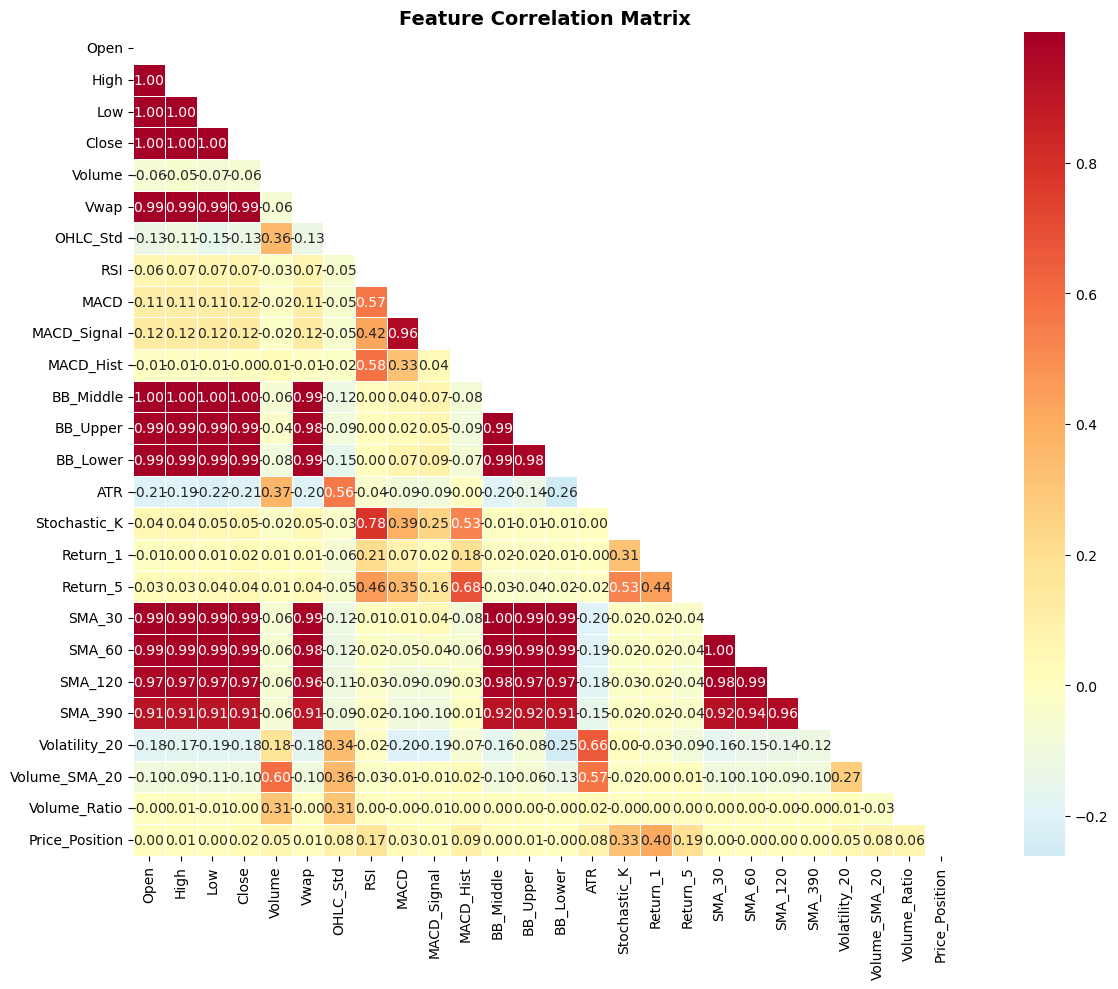

In [26]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# =============================================================================
# REMOVE HIGHLY CORRELATED FEATURES
# =============================================================================

def remove_highly_correlated(dataframe: pd.DataFrame, threshold: float = 0.65, protect_cols: list = None) -> pd.DataFrame:
    """Remove features that are highly correlated with each other
    
    Args:
        dataframe: Input DataFrame
        threshold: Correlation threshold above which to remove features
        protect_cols: List of columns to never drop (e.g., target variable)
    """
    if protect_cols is None:
        protect_cols = []
    
    corr_matrix = dataframe.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find columns with correlation greater than threshold
    to_drop = set()
    for column in upper.columns:
        correlated = upper.index[upper[column] > threshold].tolist()
        if correlated:
            to_drop.update(correlated)
    
    # Remove protected columns from the drop list
    to_drop = to_drop - set(protect_cols)
    
    return dataframe.drop(columns=list(to_drop)), list(to_drop)

print("=" * 60)
print(f"REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)")
print("=" * 60)

print(f"\nColumns BEFORE removal: {len(df.columns)}")
print(f"   {list(df.columns)}")

# Protect 'Close' from being dropped (it's our target variable)
df_reduced, dropped_cols = remove_highly_correlated(df, threshold=0.65, protect_cols=['Close'])

print(f"\n🗑️ Columns to remove (|r| > 0.65):")
for col in sorted(dropped_cols):
    print(f"   - {col}")

print(f"\n✅ Columns AFTER removal: {len(df_reduced.columns)}")
print(f"   {list(df_reduced.columns)}")

# Update df to the reduced version
df = df_reduced.copy()

print("\n" + "=" * 60)
print("UPDATED CORRELATION MATRIX (remaining features)")
print("=" * 60)
print(df.corr().round(2))

REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)

Columns BEFORE removal: 26
   ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'SMA_120', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']

🗑️ Columns to remove (|r| > 0.65):
   - ATR
   - BB_Lower
   - BB_Middle
   - BB_Upper
   - High
   - Low
   - MACD
   - MACD_Hist
   - Open
   - RSI
   - SMA_120
   - SMA_30
   - SMA_60
   - Vwap

✅ Columns AFTER removal: 12
   ['Close', 'Volume', 'OHLC_Std', 'MACD_Signal', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']

UPDATED CORRELATION MATRIX (remaining features)
                Close  Volume  OHLC_Std  MACD_Signal  Stochastic_K  Return_1  \
Close            1.00   -0.06     -0.13         0.12          0.05      0.02   
Volume   

In [28]:
# =============================================================================
# PREPARE FINAL DATASET WITH TARGET VARIABLE
# =============================================================================

# IMPORTANT: We need to preserve 'Close' as our target before feature reduction
# Get the Close column from the original cleaned data before correlation removal
# We'll use df_reduced (features without highly correlated ones) + Close from before

# First, let's rebuild df_model with the reduced features PLUS the Close column
# The Close column should come from the data BEFORE the correlation removal step

# Check what we have available
print("=" * 60)
print("BUILDING FINAL MODELING DATASET")
print("=" * 60)

# df_reduced has the non-correlated features but may not have Close
# We need to get Close from before the dropna/cleaning step

# Re-read the original df data (this requires re-running earlier cells)
# For now, let's work with what we have in the kernel

# Check if Close exists in df or df_reduced
print(f"\n📋 Available DataFrames:")
print(f"   df columns: {list(df.columns)}")
print(f"   df shape: {df.shape}")
print(f"   df_reduced columns: {list(df_reduced.columns)}")
print(f"   df_reduced shape: {df_reduced.shape}")

# If Close is not in df, we have a problem - need to re-run from feature engineering
if 'Close' not in df.columns and 'Close' not in df_reduced.columns:
    print("\n⚠️ 'Close' column is missing!")
    print("   Please re-run cells from Feature Engineering (cell 8) onwards")
    print("   This will rebuild the data pipeline with Close preserved")
else:
    # Build the modeling dataframe
    if 'Close' in df_reduced.columns:
        df_model = df_reduced.copy()
    else:
        # Get Close from df and merge with df_reduced
        df_model = df_reduced.copy()
        df_model['Close'] = df['Close']
    
    print(f"\n✅ df_model created:")
    print(f"   Shape: {df_model.shape}")
    print(f"   Columns: {list(df_model.columns)}")

BUILDING FINAL MODELING DATASET

📋 Available DataFrames:
   df columns: ['Close', 'Volume', 'OHLC_Std', 'MACD_Signal', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']
   df shape: (17937, 12)
   df_reduced columns: ['Close', 'Volume', 'OHLC_Std', 'MACD_Signal', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']
   df_reduced shape: (17937, 12)

✅ df_model created:
   Shape: (17937, 12)
   Columns: ['Close', 'Volume', 'OHLC_Std', 'MACD_Signal', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']


In [29]:
# Display final dataframe
df

,Close,Volume,OHLC_Std,MACD_Signal,Stochastic_K,Return_1,Return_5,SMA_390,Volatility_20,Volume_SMA_20,Volume_Ratio,Price_Position
timestamp,,,,,,,,,,,,
2025-12-31 16:31:00,684.8600,107595.0,0.077567,0.074722,52.136752,-1.022002e-04,-0.000212,685.841137,0.000119,136811.75,0.786446,0.542857
2025-12-31 16:32:00,684.8571,51913.0,0.054534,0.075854,42.848485,-4.234442e-06,-0.000216,685.840001,0.000118,131378.80,0.395140,0.973636
2025-12-31 16:33:00,684.8400,185189.0,0.035237,0.074597,31.818182,-2.496871e-05,-0.000358,685.838617,0.000119,128592.90,1.440118,0.411765
2025-12-31 16:34:00,684.8299,40503.0,0.058026,0.071578,29.522727,-1.474797e-05,-0.000423,685.837001,0.000118,127578.30,0.317476,0.499286
2025-12-31 16:35:00,684.8300,65744.0,0.042525,0.067450,27.906977,1.460217e-07,-0.000146,685.835411,0.000117,124599.75,0.527642,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-30 00:55:00,692.7400,745.0,0.005774,-0.118326,70.890563,1.299358e-04,0.000043,692.883268,0.000257,994.45,0.749158,1.000000
2026-01-30 00:56:00,692.8000,3097.0,0.000000,-0.111684,90.605627,8.661258e-05,0.000433,692.888576,0.000217,1135.50,2.727433,0.000000
2026-01-30 00:57:00,692.7604,914.0,0.055249,-0.104526,74.388112,-5.715935e-05,0.000087,692.893731,0.000217,1152.25,0.793231,0.000000


# Training

In [12]:
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_lightning import Trainer


c:\Users\batzi\anaconda3\envs\trading_brains\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Model Training

With limited data (87 rows), we'll use models that work well with small datasets:
1. **Ridge Regression** - baseline linear model with regularization
2. **Random Forest** - ensemble method, handles non-linearity
3. **XGBoost** - gradient boosting, often best for tabular data

We'll use walk-forward validation (time series split) to avoid data leakage.

In [30]:
# =============================================================================
# DATA PREPARATION FOR MODELING
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)

# Use df_model which should have features + Close
if 'df_model' not in dir() or df_model.shape[0] == 0:
    print("⚠️ df_model not found or empty. Attempting to rebuild...")
    # Fallback: try to use df if it has Close
    if 'Close' in df.columns and df.shape[0] > 0:
        df_model = df.copy()
        print(f"   Using df with {len(df_model)} rows")
    else:
        print("❌ ERROR: No valid data available!")
        print("   Please re-run cells from Feature Engineering onwards")
        raise ValueError("No data available for modeling")

# Ensure no NaN values
nan_count = df_model.isnull().sum().sum()
print(f"\n🔍 NaN values in df_model: {nan_count}")

if nan_count > 0:
    print(f"   Dropping {df_model.isnull().any(axis=1).sum()} rows with NaN values...")
    df_model = df_model.dropna()
    print(f"   Remaining rows: {len(df_model)}")

# Check for infinite values in numeric columns only
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df_model[numeric_cols]).any(axis=1)
if inf_mask.sum() > 0:
    print(f"   Dropping {inf_mask.sum()} rows with infinite values...")
    df_model = df_model[~inf_mask]

# Define features and target
feature_columns = [col for col in df_model.columns if col != 'Close']
X = df_model[feature_columns].astype(np.float64).values
y = df_model['Close'].astype(np.float64).values

# Final check
print(f"\n✅ Data ready for modeling:")
print(f"   Features: {feature_columns}")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

if X.shape[0] == 0:
    raise ValueError("No samples available for training! Please re-run from Feature Engineering.")

# Time Series Cross-Validation setup
n_splits = min(5, X.shape[0] // 10)  # Ensure we have enough samples per split
n_splits = max(2, n_splits)  # At least 2 splits
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n📊 Time Series Cross-Validation:")
print(f"   Number of splits: {n_splits}")

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"   Split {i+1}: Train size={len(train_idx)}, Test size={len(test_idx)}")

DATA PREPARATION FOR MODELING

🔍 NaN values in df_model: 0

✅ Data ready for modeling:
   Features: ['Volume', 'OHLC_Std', 'MACD_Signal', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position']
   X shape: (17937, 11)
   y shape: (17937,)

📊 Time Series Cross-Validation:
   Number of splits: 5
   Split 1: Train size=2992, Test size=2989
   Split 2: Train size=5981, Test size=2989
   Split 3: Train size=8970, Test size=2989
   Split 4: Train size=11959, Test size=2989
   Split 5: Train size=14948, Test size=2989


In [31]:
# =============================================================================
# MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION
# =============================================================================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost, fall back to GradientBoosting if not available
try:
    from xgboost import XGBRegressor
    use_xgboost = True
except ImportError:
    print("⚠️ XGBoost not installed, using sklearn's GradientBoostingRegressor instead")
    use_xgboost = False

# Define models to compare
if use_xgboost:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
    }
else:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
    }

# Store results
results = {name: {'rmse': [], 'mae': [], 'r2': []} for name in models.keys()}

print("=" * 60)
print("MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION")
print("=" * 60)

# Scaler for features
scaler = StandardScaler()

for name, model in models.items():
    print(f"\n🔄 Training: {name}")
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        results[name]['r2'].append(r2)
    
    avg_rmse = np.mean(results[name]['rmse'])
    avg_mae = np.mean(results[name]['mae'])
    avg_r2 = np.mean(results[name]['r2'])
    
    print(f"   Avg RMSE: ${avg_rmse:.4f}")
    print(f"   Avg MAE:  ${avg_mae:.4f}")
    print(f"   Avg R²:   {avg_r2:.4f}")

# Summary comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

summary_data = []
for name in models.keys():
    summary_data.append({
        'Model': name,
        'Avg RMSE': np.mean(results[name]['rmse']),
        'Std RMSE': np.std(results[name]['rmse']),
        'Avg MAE': np.mean(results[name]['mae']),
        'Avg R²': np.mean(results[name]['r2'])
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Best model
best_model_name = summary_df.loc[summary_df['Avg RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")

⚠️ XGBoost not installed, using sklearn's GradientBoostingRegressor instead
MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION

🔄 Training: Ridge Regression
   Avg RMSE: $1.6919
   Avg MAE:  $1.2090
   Avg R²:   0.6264

🔄 Training: Random Forest
   Avg RMSE: $2.4271
   Avg MAE:  $1.8954
   Avg R²:   0.2748

🔄 Training: Gradient Boosting
   Avg RMSE: $2.3862
   Avg MAE:  $1.8365
   Avg R²:   0.3065

MODEL COMPARISON SUMMARY
            Model  Avg RMSE  Std RMSE  Avg MAE   Avg R²
 Ridge Regression  1.691881  0.393878 1.209019 0.626448
    Random Forest  2.427080  0.738962 1.895439 0.274827
Gradient Boosting  2.386195  0.704418 1.836481 0.306525

🏆 Best Model: Ridge Regression


FINAL MODEL EVALUATION (Ridge Regression)

📊 Holdout Set Performance (last 500 samples):
   RMSE: $2.7268
   MAE:  $2.1521
   R²:   -1.7332


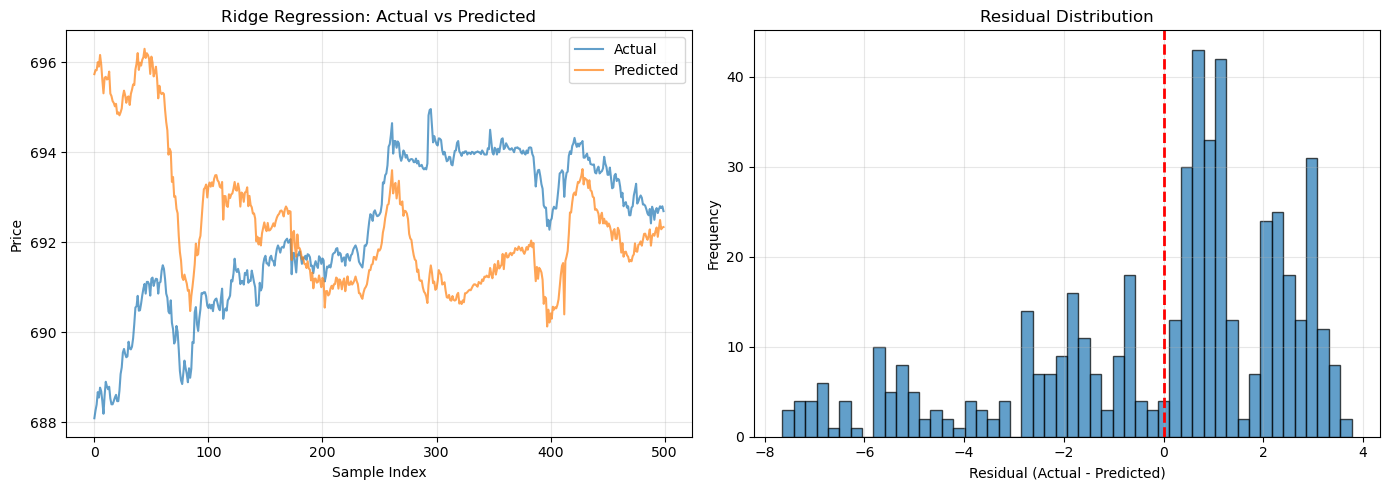


📊 Feature Coefficients (Ridge):
       Feature  Coefficient
       SMA_390     4.447317
   MACD_Signal     1.015228
      Return_5     0.187245
      OHLC_Std    -0.117414
 Volatility_20    -0.080476
      Return_1     0.062524
 Volume_SMA_20     0.055277
  Volume_Ratio     0.045885
  Stochastic_K    -0.043371
        Volume     0.019400
Price_Position     0.012833


In [32]:
# =============================================================================
# FINAL MODEL EVALUATION
# =============================================================================
import matplotlib.pyplot as plt

# Use the best model for final evaluation
# Train on all but the last N samples, test on the last N
holdout_size = min(500, int(len(X) * 0.1))  # 10% or 500 samples for holdout

X_train_final = X[:-holdout_size]
X_test_final = X[-holdout_size:]
y_train_final = y[:-holdout_size]
y_test_final = y[-holdout_size:]

# Scale
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Train best model (based on results)
if best_model_name == 'Ridge Regression':
    best_model = Ridge(alpha=1.0)
elif best_model_name == 'Random Forest':
    best_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
elif best_model_name == 'XGBoost' and use_xgboost:
    best_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
else:
    best_model = GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

best_model.fit(X_train_scaled, y_train_final)
y_pred_final = best_model.predict(X_test_scaled)

# Final metrics
final_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test_final, y_pred_final)

print("=" * 60)
print(f"FINAL MODEL EVALUATION ({best_model_name})")
print("=" * 60)
print(f"\n📊 Holdout Set Performance (last {holdout_size} samples):")
print(f"   RMSE: ${final_rmse:.4f}")
print(f"   MAE:  ${final_mae:.4f}")
print(f"   R²:   {final_r2:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].plot(y_test_final, label='Actual', alpha=0.7)
axes[0].plot(y_pred_final, label='Predicted', alpha=0.7)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Price')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_final - y_pred_final
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print("\n📊 Feature Importance:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importance_df.to_string(index=False))
elif hasattr(best_model, 'coef_'):
    print("\n📊 Feature Coefficients (Ridge):")
    coef_df = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(coef_df.to_string(index=False))